# Tensor Decomposition

The purpose of this notebook is to:
- Load the preprocessed MEG tensor.
- Inspect the tensor to understand its structure.
- Apply several tensor decomposition methods.
- Compare how well each decomposition compresses and reconstructs the original tensor.

The input to this notebook is the preprocessed tensor saved during preprocessing, while the outputs are the decomposed tensor representations and their reconstruction errors.

- SNR
- Reconstruction error
- Compression ratio

After 20 trials, OPMs reached an average SNR that was higher than the average SNR of EEG after 80 trials and of SQUID after 40 trials. Overall, there was an increase in SNR for OPMs of up to 205% compared to EEG and of up to 40% compared to SQUID. The SNR of OPM signals was significantly higher than that of SQUID signals for 20, 50, 60, 70, and 80 trials. In addition, the SNR of SQUID signals was characterized by significantly higher SNR compared to EEG signals (for all apart from 1 and 20 trials). In general, maximum SNRs for OPM signals were 38% higher than for SQUID signals and 210% higher than for EEG signals (Figure 2B).
OPMs have significantly higher SNRs compared to EEG and SQUID
(A) Signal-to-noise ratios (SNRs) of OPMs over trial numbers. The SNRs of OPMs were significantly higher than those of EEG and SQUID. Even when comparing only the first trial of each individual, OPMs have a significantly higher SNR compared to EEG
https://www.sciencedirect.com/science/article/pii/S2589004226008643

In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.13 install --upgrade pip


In [3]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [2]:
from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from tensorly.decomposition import parafac, tucker, tensor_train
from tensorly.cp_tensor import cp_to_tensor
from tensorly.tucker_tensor import tucker_to_tensor
from tensorly.tt_tensor import tt_to_tensor


## Experiment 1: Rank [3, 5, 7, 10] fixed for all decompositions

In [ ]:
# ============================= PATH ===============================


LOADED_ROOT = Path("../data/preprocessed")
SAVE_ROOT = Path("../results")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_ROOT = SAVE_ROOT / "plots"
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

files = sorted(LOADED_ROOT.rglob("*.npz"))

print(f"Found {len(files)} preprocessed files.")

if len(files) == 0:
    raise FileNotFoundError(
        f"No .npz files found in {LOADED_ROOT.resolve()}"
    )

# ============================= SETTINGS ===============================

# Candidate ranks
CP_RANKS = [3, 5, 7, 10]
TUCKER_RANKS = [3, 5, 7, 10]
TT_RANKS = [3, 5, 7, 10]

N_ITER_MAX = 100

# ============================= FUNCTIONS ===============================

def infer_subject_task_run(file):
    """
    Expected structure:

        ../data/preprocessed/
            002/
                auditory/
                    run01_epochs.npz

    Returns:
        subject = "002"
        task    = "auditory"
        run     = "run01"
    """

    subject = file.parent.parent.name
    task = file.parent.name

    # run01_epochs.npz -> run01
    run = file.stem.replace("_epochs", "")

    return subject, task, run

def relative_reconstruction_error(X, X_hat):
    """
    Relative Frobenius reconstruction error:

        ||X - X_hat||_F / ||X||_F
    """
    numerator = np.linalg.norm(X - X_hat)
    denominator = np.linalg.norm(X)

    if denominator == 0:
        return np.nan

    return numerator / denominator

def compression_ratio(original_shape, compressed_parameters):
    """
    Fraction of parameters saved.

    Returns:
        compression_ratio = 1 - compressed/original

    Example:
        0.90 = 90% fewer parameters
    """
    original_parameters = int(np.prod(original_shape))

    if original_parameters == 0:
        return np.nan

    return 1.0 - (compressed_parameters / original_parameters)

def compression_factor(original_shape, compressed_parameters):
    """
    Original parameters / compressed parameters.

    Example:
        10 means the representation is approximately 10x smaller.
    """
    original_parameters = int(np.prod(original_shape))

    if compressed_parameters == 0:
        return np.nan

    return original_parameters / compressed_parameters

def explained_variance(X, X_hat):
    """
    Explained variance based on reconstruction error.
    """

    total_energy = np.sum(X ** 2)
    residual_energy = np.sum((X - X_hat) ** 2)

    if total_energy == 0:
        return np.nan

    return 1.0 - (residual_energy / total_energy)

def cp_parameter_count(weights, factors):
    """
    Number of parameters stored by CP decomposition.

    CP:
        weights: R
        factor matrices:
            I x R
            J x R
            K x R
    """
    count = len(weights)

    for factor in factors:
        count += factor.size

    return int(count)

def tucker_parameter_count(core, factors):
    """
    Number of parameters stored by Tucker decomposition.

    Includes:
        core tensor
        all factor matrices
    """
    count = core.size

    for factor in factors:
        count += factor.size

    return int(count)

def tt_parameter_count(tt_cores):
    """
    Number of parameters stored by TT decomposition.
    """
    return int(sum(core.size for core in tt_cores))

def calculate_snr(X):
    """
    Approximate trial-based SNR.

    The mean across trials is treated as the reproducible
    signal component.

        signal = mean across trials
        noise  = individual trial - mean

        SNR = RMS(signal) / RMS(noise)

    Returns:
        SNR in dB.
    """
    if X.shape[0] < 2:
        return np.nan

    # Average response across trials
    signal = np.mean(X, axis=0)

    # Trial-to-trial residual
    noise = X - signal

    signal_rms = np.sqrt(np.mean(signal ** 2))
    noise_rms = np.sqrt(np.mean(noise ** 2))

    if noise_rms == 0:
        return np.inf

    snr_linear = signal_rms / noise_rms

    return 20 * np.log10(snr_linear)

# ============================= STORAGE ===============================

decomposition_results = []
signal_results = []

# ============================= MAIN ===============================

for file_index, file in enumerate(files, start=1):

    print("\n" + "=" * 70)
    print(f"[{file_index}/{len(files)}] {file}")
    print("=" * 70)

    # ---------- LOAD ----------

    tensor = np.load(file, allow_pickle=True)

    X = tensor["epochs"].astype(np.float64)

    times = tensor["times"] if "times" in tensor else None
    fs = float(tensor["fs"]) if "fs" in tensor else np.nan

    print(f"Tensor shape: {X.shape}")
    print(f"Sampling frequency: {fs}")

    subject, task, run = infer_subject_task_run(file)

    print(f"Subject: {subject}")
    print(f"Task: {task}")
    print(f"Run: {run}")

    # ---------- SIGNAL METRICS ----------

    print("\nCalculating signal metrics...")

    snr = calculate_snr(X)

    print(f"SNR:  {snr:.4f} dB")

    signal_results.append({
        "File": str(file),
        "Subject": subject,
        "Task": task,
        "Run": run,
        "Trials": X.shape[0],
        "Channels": X.shape[1],
        "Timepoints": X.shape[2],
        "Sampling_Frequency_Hz": fs,
        "SNR_dB": snr,
    })

    # ---------- CP DECOMPOSITION ----------

    print("\n--- CP decomposition ---")

    cp_errors = []

    for rank in CP_RANKS:

        print(f"CP rank = {rank}")

        start_time = time.perf_counter()

        cp = parafac(
            X,
            rank=rank,
            init="random", # svd was too large
            n_iter_max=N_ITER_MAX,
            tol=1e-6,
            verbose=False
        )

        elapsed = time.perf_counter() - start_time

        weights, factors = cp

        # Reconstruct tensor
        X_hat = cp_to_tensor(cp)

        error = relative_reconstruction_error(X, X_hat)
        ev = explained_variance(X, X_hat)

        # Number of stored parameters
        parameters = cp_parameter_count(
            weights,
            factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        cp_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "CP",
            "Rank": str(rank),
            "Rank_Numeric": rank,
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- TUCKER DECOMPOSITION ----------

    print("\n--- Tucker decomposition ---")

    tucker_errors = []

    for rank in TUCKER_RANKS:

        # Same rank in all three modes
        actual_rank = [
            min(rank, X.shape[0]),
            min(rank, X.shape[1]),
            min(rank, X.shape[2]),
        ]

        print(f"Tucker rank = {actual_rank}")

        start_time = time.perf_counter()

        tucker_model = tucker(
            X,
            rank=actual_rank,
            init="random", # svd was too large
            n_iter_max=N_ITER_MAX,
            tol=1e-6
        )

        elapsed = time.perf_counter() - start_time

        core, factors = tucker_model

        X_hat = tucker_to_tensor(tucker_model)

        ev = explained_variance(X, X_hat)

        error = relative_reconstruction_error(
            X,
            X_hat
        )

        parameters = tucker_parameter_count(
            core,
            factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        tucker_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "Tucker",
            "Rank": str(tuple(actual_rank)),
            "Rank_Numeric": rank,
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- TT DECOMPOSITION ----------

    print("\n--- TT decomposition ---")

    tt_errors = []

    for rank in TT_RANKS:

        # For a third-order tensor:
        #
        # [1, r, r, 1]
        #
        # corresponds to:
        #
        # 200 -- r -- r -- 1401

        actual_rank = [
            1,
            min(rank, X.shape[0]),
            min(rank, X.shape[1]),
            1
        ]

        print(f"TT rank = {actual_rank}")

        start_time = time.perf_counter()

        tt_model = tensor_train(
            X,
            rank=actual_rank
        )

        elapsed = time.perf_counter() - start_time

        X_hat = tt_to_tensor(tt_model)

        ev = explained_variance(X, X_hat)

        error = relative_reconstruction_error(
            X,
            X_hat
        )

        parameters = tt_parameter_count(
            tt_model.factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        tt_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "TT",
            "Rank": str(tuple(actual_rank)),
            "Rank_Numeric": rank,
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- SAVE ----------

    safe_subject = str(subject).replace("/", "_")
    safe_task = str(task).replace("/", "_")
    safe_run = str(run).replace("/", "_")

    prefix = (
        f"{safe_subject}_{safe_task}_{safe_run}"
    )

    # ---------- RECONSTRUCTION ERROR ----------

    plt.figure(figsize=(8, 5))

    plt.plot(
        CP_RANKS,
        [x["Reconstruction_Error"] for x in cp_errors],
        marker="o",
        label="CP"
    )

    plt.plot(
        TUCKER_RANKS,
        [x["Reconstruction_Error"] for x in tucker_errors],
        marker="o",
        label="Tucker"
    )

    plt.plot(
        TT_RANKS,
        [x["Reconstruction_Error"] for x in tt_errors],
        marker="o",
        label="TT"
    )

    plt.xlabel("Rank")
    plt.ylabel("Relative Reconstruction Error")
    plt.title(
        f"Reconstruction Error\n"
        f"Subject {subject} - {task} - {run}"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_ROOT / f"{prefix}_reconstruction_error.png",
        dpi=300
    )

    plt.close()

    # ---------- COMPRESSION RATIO ----------

    cp_compression = [
        x["Compression_Ratio"]
        for x in decomposition_results
        if (
            x["File"] == str(file)
            and x["Method"] == "CP"
        )
    ]

    tucker_compression = [
        x["Compression_Ratio"]
        for x in decomposition_results
        if (
            x["File"] == str(file)
            and x["Method"] == "Tucker"
        )
    ]

    tt_compression = [
        x["Compression_Ratio"]
        for x in decomposition_results
        if (
            x["File"] == str(file)
            and x["Method"] == "TT"
        )
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        CP_RANKS,
        cp_compression,
        marker="o",
        label="CP"
    )

    plt.plot(
        TUCKER_RANKS,
        tucker_compression,
        marker="o",
        label="Tucker"
    )

    plt.plot(
        TT_RANKS,
        tt_compression,
        marker="o",
        label="TT"
    )

    plt.xlabel("Rank")
    plt.ylabel("Compression Ratio")
    plt.title(
        f"Compression Ratio\n"
        f"Subject {subject} - {task} - {run}"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_ROOT / f"{prefix}_compression_ratio.png",
        dpi=300
    )

    plt.close()


# ---------- DATAFRAME ----------

df_decomp = pd.DataFrame(
    decomposition_results
)

df_signal = pd.DataFrame(
    signal_results
)


# ---------- SUMMARY ----------

summary = (
    df_decomp
    .groupby(
        [
            "Subject",
            "Task",
            "Method",
            "Rank"
        ],
        dropna=False
    )
    .agg(
        Mean_Reconstruction_Error=(
            "Reconstruction_Error",
            "mean"
        ),
        Std_Reconstruction_Error=(
            "Reconstruction_Error",
            "std"
        ),
        Mean_Compression_Ratio=(
            "Compression_Ratio",
            "mean"
        ),
        Std_Compression_Ratio=(
            "Compression_Ratio",
            "std"
        ),
        Mean_Compression_Factor=(
            "Compression_Factor",
            "mean"
        ),
        Mean_Runtime_Seconds=(
            "Runtime_Seconds",
            "mean"
        ),
        N=("File", "count")
    )
    .reset_index()
)


# ---------- OVERALL SUMMARY ----------

overall_summary = (
    df_decomp
    .groupby(
        [
            "Method",
            "Rank"
        ],
        dropna=False
    )
    .agg(
        Mean_Reconstruction_Error=(
            "Reconstruction_Error",
            "mean"
        ),
        Std_Reconstruction_Error=(
            "Reconstruction_Error",
            "std"
        ),
        Mean_Compression_Ratio=(
            "Compression_Ratio",
            "mean"
        ),
        Std_Compression_Ratio=(
            "Compression_Ratio",
            "std"
        ),
        Mean_Compression_Factor=(
            "Compression_Factor",
            "mean"
        ),
        Mean_Runtime_Seconds=(
            "Runtime_Seconds",
            "mean"
        ),
        N=("File", "count")
    )
    .reset_index()
)


# ---------- SIGNAL METRIC SUMMARY ----------

signal_summary = (
    df_signal
    .groupby(
        ["Subject", "Task"],
        dropna=False
    )
    .agg(
        Mean_SNR_dB=("SNR_dB", "mean"),
        Std_SNR_dB=("SNR_dB", "std"),
        N=("File", "count")
    )
    .reset_index()
)


# ---------- SAVE EXCEL ----------

excel_path = SAVE_ROOT / "tensor_decomposition_results.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df_decomp.to_excel(
        writer,
        sheet_name="Decomposition_Metrics",
        index=False
    )

    df_signal.to_excel(
        writer,
        sheet_name="Signal_Metrics",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Subject_Task_Summary",
        index=False
    )

    overall_summary.to_excel(
        writer,
        sheet_name="Overall_Summary",
        index=False
    )

    signal_summary.to_excel(
        writer,
        sheet_name="Signal_Summary",
        index=False
    )


# ============================================================
# OVERALL PLOTS
# ============================================================

# ------------------------------------------------------------
# Overall reconstruction error
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for method in ["CP", "Tucker", "TT"]:

    subset = overall_summary[
        overall_summary["Method"] == method
    ]

    plt.plot(
        subset["Rank_Numeric"]
        if "Rank_Numeric" in subset.columns
        else range(len(subset)),
        subset["Mean_Reconstruction_Error"],
        marker="o",
        label=method
    )

plt.xlabel("Rank")
plt.ylabel("Mean Relative Reconstruction Error")
plt.title("Mean Reconstruction Error Across Dataset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_ROOT / "overall_reconstruction_error.png",
    dpi=300
)

plt.close()


# ------------------------------------------------------------
# Overall compression
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for method in ["CP", "Tucker", "TT"]:

    subset = overall_summary[
        overall_summary["Method"] == method
    ]

    plt.plot(
        range(len(subset)),
        subset["Mean_Compression_Ratio"],
        marker="o",
        label=method
    )

plt.xlabel("Rank")
plt.ylabel("Mean Compression Ratio")
plt.title("Mean Compression Ratio Across Dataset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_ROOT / "overall_compression_ratio.png",
    dpi=300
)

plt.close()


print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

print(f"Excel file:")
print(excel_path.resolve())

print("\nPlots:")
print(PLOT_ROOT.resolve())

print("\nRows in decomposition results:", len(df_decomp))
print("Signal metric records:", len(df_signal))

Found 32 preprocessed files.

[1/32] ../data/preprocessed/002/auditory/run01_epochs.npz
Tensor shape: (200, 30, 1401)
Sampling frequency: 2000.0
Subject: 002
Task: auditory
Run: run01

Calculating signal metrics...
SNR:  -20.3566 dB

--- CP decomposition ---
CP rank = 3
CP rank = 5
CP rank = 7
CP rank = 10

--- Tucker decomposition ---
Tucker rank = [3, 3, 3]
Tucker rank = [5, 5, 5]
Tucker rank = [7, 7, 7]
Tucker rank = [10, 10, 10]

--- TT decomposition ---
TT rank = [1, 3, 3, 1]
TT rank = [1, 5, 5, 1]
TT rank = [1, 7, 7, 1]
TT rank = [1, 10, 10, 1]

[2/32] ../data/preprocessed/002/auditory/run02_epochs.npz
Tensor shape: (200, 30, 1401)
Sampling frequency: 2000.0
Subject: 002
Task: auditory
Run: run02

Calculating signal metrics...
SNR:  -26.2462 dB

--- CP decomposition ---
CP rank = 3
CP rank = 5
CP rank = 7
CP rank = 10

--- Tucker decomposition ---
Tucker rank = [3, 3, 3]
Tucker rank = [5, 5, 5]
Tucker rank = [7, 7, 7]
Tucker rank = [10, 10, 10]

--- TT decomposition ---
TT rank =

## Experiment 2: Different Ranks


- CP_RANKS = [1, 2, 3, 5, 8, 10, 15, 20, 30]
- TUCKER_RANKS = [
    (5, 3, 10),
    (10, 5, 20),
    (20, 10, 40),
    (30, 15, 60),
    (50, 20, 100),
    (75, 25, 150),
    (100, 30, 200)
]
- TT_RANKS = [
    (1, 2, 2, 1),
    (1, 2, 3, 1),
    (1, 3, 3, 1),
    (1, 4, 5, 1),
    (1, 10, 10, 1),
    (1, 10, 15, 1),
    (1, 15, 20, 1),
    (1, 20, 20, 1),
]

This is much more meaningful because the three dimensions have very different sizes:
- trials = 200
- sensors = 30
- time points = 1401

In [ ]:
# Candidate ranks
CP_RANKS = [1, 2, 3, 5, 8, 10, 15, 20, 30]
TUCKER_RANKS = [
    (5, 3, 10),
    (10, 5, 20),
    (20, 10, 40),
    (30, 15, 60),
    (50, 20, 100),
    (75, 25, 150),
    (100, 30, 200)
]
TT_RANKS = [
    (1, 2, 2, 1),
    (1, 2, 3, 1),
    (1, 3, 3, 1),
    (1, 4, 5, 1),
    (1, 10, 10, 1),
    (1, 10, 15, 1),
    (1, 15, 20, 1),
    (1, 20, 20, 1),
]

In [14]:
# ============================= PATH ===============================

LOADED_ROOT = Path("../data/preprocessed")
SAVE_ROOT = Path("../results/decomposition_experiment2")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_ROOT = SAVE_ROOT / "plots"
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

files = sorted(LOADED_ROOT.rglob("*.npz"))

print(f"Found {len(files)} preprocessed files.")

if len(files) == 0:
    raise FileNotFoundError(
        f"No .npz files found in {LOADED_ROOT.resolve()}"
    )

# ============================= SETTINGS ===============================

# Candidate ranks
CP_RANKS = [1, 2, 3, 5, 8, 10, 15, 20, 30]
TUCKER_RANKS = [
    (5, 3, 10),
    (10, 5, 20),
    (20, 10, 40),
    (30, 15, 60),
    (50, 20, 100),
    (75, 25, 150),
    (100, 30, 200)
]
TT_RANKS = [
    (1, 2, 2, 1),
    (1, 2, 3, 1),
    (1, 3, 3, 1),
    (1, 4, 5, 1),
    (1, 10, 10, 1),
    (1, 10, 15, 1),
    (1, 15, 20, 1),
    (1, 20, 20, 1),
]

N_ITER_MAX = 100

# ============================= FUNCTIONS ===============================

def infer_subject_task_run(file):
    """
    Expected structure:

        ../data/preprocessed/
            002/
                auditory/
                    run01_epochs.npz

    Returns:
        subject = "002"
        task    = "auditory"
        run     = "run01"
    """

    subject = file.parent.parent.name
    task = file.parent.name

    # run01_epochs.npz -> run01
    run = file.stem.replace("_epochs", "")

    return subject, task, run

def relative_reconstruction_error(X, X_hat):
    """
    Relative Frobenius reconstruction error:

        ||X - X_hat||_F / ||X||_F
    """
    numerator = np.linalg.norm(X - X_hat)
    denominator = np.linalg.norm(X)

    if denominator == 0:
        return np.nan

    return numerator / denominator

def compression_ratio(original_shape, compressed_parameters):
    """
    Fraction of parameters saved.

    Returns:
        compression_ratio = 1 - compressed/original

    Example:
        0.90 = 90% fewer parameters
    """
    original_parameters = int(np.prod(original_shape))

    if original_parameters == 0:
        return np.nan

    return 1.0 - (compressed_parameters / original_parameters)

def compression_factor(original_shape, compressed_parameters):
    """
    Original parameters / compressed parameters.

    Example:
        10 means the representation is approximately 10x smaller.
    """
    original_parameters = int(np.prod(original_shape))

    if compressed_parameters == 0:
        return np.nan

    return original_parameters / compressed_parameters

def explained_variance(X, X_hat):
    """
    Explained variance based on reconstruction error.
    """

    total_energy = np.sum(X ** 2)
    residual_energy = np.sum((X - X_hat) ** 2)

    if total_energy == 0:
        return np.nan

    return 1.0 - (residual_energy / total_energy)

def cp_parameter_count(weights, factors):
    """
    Number of parameters stored by CP decomposition.

    CP:
        weights: R
        factor matrices:
            I x R
            J x R
            K x R
    """
    count = len(weights)

    for factor in factors:
        count += factor.size

    return int(count)

def tucker_parameter_count(core, factors):
    """
    Number of parameters stored by Tucker decomposition.

    Includes:
        core tensor
        all factor matrices
    """
    count = core.size

    for factor in factors:
        count += factor.size

    return int(count)

def tt_parameter_count(tt_cores):
    """
    Number of parameters stored by TT decomposition.
    """
    return int(sum(core.size for core in tt_cores))

def calculate_snr(X):
    """
    Approximate trial-based SNR.

    The mean across trials is treated as the reproducible
    signal component.

        signal = mean across trials
        noise  = individual trial - mean

        SNR = RMS(signal) / RMS(noise)

    Returns:
        SNR in dB.
    """
    if X.shape[0] < 2:
        return np.nan

    # Average response across trials
    signal = np.mean(X, axis=0)

    # Trial-to-trial residual
    noise = X - signal

    signal_rms = np.sqrt(np.mean(signal ** 2))
    noise_rms = np.sqrt(np.mean(noise ** 2))

    if noise_rms == 0:
        return np.inf

    snr_linear = signal_rms / noise_rms

    return 20 * np.log10(snr_linear)

# ============================= STORAGE ===============================

decomposition_results = []
signal_results = []

# ============================= MAIN ===============================

for file_index, file in enumerate(files, start=1):

    print("\n" + "=" * 70)
    print(f"[{file_index}/{len(files)}] {file}")
    print("=" * 70)

    # ---------- LOAD ----------

    tensor = np.load(file, allow_pickle=True)

    X = tensor["epochs"].astype(np.float64)

    times = tensor["times"] if "times" in tensor else None
    fs = float(tensor["fs"]) if "fs" in tensor else np.nan

    print(f"Tensor shape: {X.shape}")
    print(f"Sampling frequency: {fs}")

    subject, task, run = infer_subject_task_run(file)

    print(f"Subject: {subject}")
    print(f"Task: {task}")
    print(f"Run: {run}")

    # ---------- SIGNAL METRICS ----------

    print("\nCalculating signal metrics...")

    snr = calculate_snr(X)

    print(f"SNR:  {snr:.4f} dB")

    signal_results.append({
        "File": str(file),
        "Subject": subject,
        "Task": task,
        "Run": run,
        "Trials": X.shape[0],
        "Channels": X.shape[1],
        "Timepoints": X.shape[2],
        "Sampling_Frequency_Hz": fs,
        "SNR_dB": snr,
    })

    # ---------- CP DECOMPOSITION ----------

    print("\n--- CP decomposition ---")

    cp_errors = []

    for rank in CP_RANKS:

        print(f"CP rank = {rank}")

        start_time = time.perf_counter()

        cp = parafac(
            X,
            rank=rank,
            init="random", # svd was too large
            n_iter_max=N_ITER_MAX,
            tol=1e-6,
            verbose=False
        )

        elapsed = time.perf_counter() - start_time

        weights, factors = cp

        # Reconstruct tensor
        X_hat = cp_to_tensor(cp)

        error = relative_reconstruction_error(X, X_hat)
        ev = explained_variance(X, X_hat)

        # Number of stored parameters
        parameters = cp_parameter_count(
            weights,
            factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        cp_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "CP",
            "Rank": str(rank),
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- TUCKER DECOMPOSITION ----------

    print("\n--- Tucker decomposition ---")

    tucker_errors = []

    for rank in TUCKER_RANKS:

        actual_rank = [
            min(rank[0], X.shape[0]),
            min(rank[1], X.shape[1]),
            min(rank[2], X.shape[2]),
        ]

        print(f"Tucker rank = {actual_rank}")

        start_time = time.perf_counter()

        tucker_model = tucker(
            X,
            rank=actual_rank,
            init="random", # svd was too large
            n_iter_max=N_ITER_MAX,
            tol=1e-6
        )

        elapsed = time.perf_counter() - start_time

        core, factors = tucker_model

        X_hat = tucker_to_tensor(tucker_model)

        ev = explained_variance(X, X_hat)

        error = relative_reconstruction_error(
            X,
            X_hat
        )

        parameters = tucker_parameter_count(
            core,
            factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        tucker_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "Tucker",
            "Rank": str(tuple(actual_rank)),
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- TT DECOMPOSITION ----------

    print("\n--- TT decomposition ---")

    tt_errors = []

    for rank in TT_RANKS:

        # For a third-order tensor:
        #
        # [1, r, r, 1]
        #
        # corresponds to:
        #
        # 200 -- r -- r -- 1401

        actual_rank = list(rank)

        print(f"TT rank = {actual_rank}")

        start_time = time.perf_counter()

        tt_model = tensor_train(
            X,
            rank=actual_rank
        )

        elapsed = time.perf_counter() - start_time

        X_hat = tt_to_tensor(tt_model)

        ev = explained_variance(X, X_hat)

        error = relative_reconstruction_error(
            X,
            X_hat
        )

        parameters = tt_parameter_count(
            tt_model.factors
        )

        comp_ratio = compression_ratio(
            X.shape,
            parameters
        )

        comp_factor = compression_factor(
            X.shape,
            parameters
        )

        tt_errors.append({
            "Rank": rank,
            "Reconstruction_Error": error,
            "Compression_Ratio": comp_ratio,
        })

        decomposition_results.append({
            "File": str(file),
            "Subject": subject,
            "Task": task,
            "Run": run,
            "Method": "TT",
            "Rank": str(tuple(actual_rank)),
            "Original_Parameters": int(np.prod(X.shape)),
            "Compressed_Parameters": parameters,
            "Compression_Ratio": comp_ratio,
            "Compression_Factor": comp_factor,
            "Reconstruction_Error": error,
            "Reconstruction_Error_Percent": error * 100,
            "Explained_Variance": ev,
            "Explained_Variance_Percent": ev * 100,
            "Runtime_Seconds": elapsed,
            "SNR_dB": snr,
        })

        del X_hat

    # ---------- SAVE ----------

    safe_subject = str(subject).replace("/", "_")
    safe_task = str(task).replace("/", "_")
    safe_run = str(run).replace("/", "_")

    prefix = (
        f"{safe_subject}_{safe_task}_{safe_run}"
    )


# ---------- DATAFRAME ----------

df_decomp = pd.DataFrame(
    decomposition_results
)

df_signal = pd.DataFrame(
    signal_results
)

# ---------- SUMMARY ----------

summary = (
    df_decomp
    .groupby(
        [
            "Subject",
            "Task",
            "Method",
            "Rank"
        ],
        dropna=False
    )
    .agg(
        Mean_Reconstruction_Error=(
            "Reconstruction_Error",
            "mean"
        ),
        Std_Reconstruction_Error=(
            "Reconstruction_Error",
            "std"
        ),
        Mean_Compression_Ratio=(
            "Compression_Ratio",
            "mean"
        ),
        Std_Compression_Ratio=(
            "Compression_Ratio",
            "std"
        ),
        Mean_Compression_Factor=(
            "Compression_Factor",
            "mean"
        ),
        Mean_Compressed_Parameters=(
            "Compressed_Parameters",
            "mean"
        ),
        Mean_Runtime_Seconds=(
            "Runtime_Seconds",
            "mean"
        ),
        N=("File", "count")
    )
    .reset_index()
)


# ---------- OVERALL SUMMARY ----------

overall_summary = (
    df_decomp
    .groupby(
        [
            "Method",
            "Rank",
        ],
        dropna=False
    )
    .agg(
        Mean_Reconstruction_Error=(
            "Reconstruction_Error",
            "mean"
        ),
        Std_Reconstruction_Error=(
            "Reconstruction_Error",
            "std"
        ),
        Mean_Compression_Ratio=(
            "Compression_Ratio",
            "mean"
        ),
        Std_Compression_Ratio=(
            "Compression_Ratio",
            "std"
        ),
        Mean_Compression_Factor=(
            "Compression_Factor",
            "mean"
        ),
        Mean_Compressed_Parameters=(
            "Compressed_Parameters",
            "mean"
        ),
        Mean_Runtime_Seconds=(
            "Runtime_Seconds",
            "mean"
        ),
        N=("File", "count")
    )
    .reset_index()
)

# ---------- SIGNAL METRIC SUMMARY ----------

signal_summary = (
    df_signal
    .groupby(
        ["Subject", "Task"],
        dropna=False
    )
    .agg(
        Mean_SNR_dB=("SNR_dB", "mean"),
        Std_SNR_dB=("SNR_dB", "std"),
        N=("File", "count")
    )
    .reset_index()
)

# ---------- SAVE EXCEL ----------

excel_path = SAVE_ROOT / "tensor_decomposition_results.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df_decomp.to_excel(
        writer,
        sheet_name="Decomposition_Metrics",
        index=False
    )

    df_signal.to_excel(
        writer,
        sheet_name="Signal_Metrics",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Subject_Task_Summary",
        index=False
    )

    overall_summary.to_excel(
        writer,
        sheet_name="Overall_Summary",
        index=False
    )

    signal_summary.to_excel(
        writer,
        sheet_name="Signal_Summary",
        index=False
    )


# ============================================================
# OVERALL PLOTS
# ============================================================

# ------------------------------------------------------------
# Reconstruction error vs number of parameters
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for method in ["CP", "Tucker", "TT"]:

    subset = overall_summary[
        overall_summary["Method"] == method
    ].copy()

    subset = subset.sort_values("Mean_Compressed_Parameters")

    x = subset["Mean_Compressed_Parameters"].to_numpy()
    y = subset["Mean_Reconstruction_Error"].to_numpy()

    plt.plot(
        x,
        y,
        marker="o",
        label=method
    )

plt.xlabel("Number of Stored Parameters")
plt.ylabel("Mean Relative Reconstruction Error")

plt.title(
    "Reconstruction Error vs Number of Stored Parameters"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.xscale("log")

plt.savefig(
    PLOT_ROOT / "reconstruction_error_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# Explained variance
# ------------------------------------------------------------

explained_summary = (
    df_decomp
    .groupby(
        ["Method", "Rank"],
        dropna=False
    )
    .agg(
        Mean_Explained_Variance=(
            "Explained_Variance",
            "mean"
        ),
        Std_Explained_Variance=(
            "Explained_Variance",
            "std"
        ),
        Mean_Compressed_Parameters=(
            "Compressed_Parameters",
            "mean"
        )
    )
    .reset_index()
)

plt.figure(figsize=(10, 7))

for method in ["CP", "Tucker", "TT"]:

    subset = explained_summary[
        explained_summary["Method"] == method
    ].copy()

    subset = subset.sort_values(
        "Mean_Compressed_Parameters"
    )

    x = subset["Mean_Compressed_Parameters"].to_numpy()
    y = subset["Mean_Explained_Variance"].to_numpy()

    plt.plot(
        x,
        y,
        marker="o",
        label=method
    )

plt.xlabel("Number of Stored Parameters")
plt.ylabel("Mean Explained Variance")

plt.title(
    "Explained Variance vs Number of Stored Parameters"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.xscale("log")

plt.savefig(
    PLOT_ROOT / "explained_variance_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# Runtime comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for method in ["CP", "Tucker", "TT"]:

    subset = overall_summary[
        overall_summary["Method"] == method
    ].copy()

    subset = subset.sort_values(
        "Mean_Compressed_Parameters"
    )

    x = subset["Mean_Compressed_Parameters"].to_numpy()
    y = subset["Mean_Runtime_Seconds"].to_numpy()

    plt.plot(
        x,
        y,
        marker="o",
        label=method
    )

plt.xlabel("Number of Stored Parameters")
plt.ylabel("Mean Runtime (seconds)")

plt.title(
    "Decomposition Runtime vs Number of Stored Parameters"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.xscale("log")

plt.savefig(
    PLOT_ROOT / "runtime_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# Compression vs reconstruction error
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for method in ["CP", "Tucker", "TT"]:

    subset = df_decomp[
        df_decomp["Method"] == method
    ]

    plt.scatter(
        subset["Compression_Ratio"],
        subset["Reconstruction_Error"],
        alpha=0.5,
        label=method
    )

plt.xlabel("Compression Ratio")
plt.ylabel("Relative Reconstruction Error")

plt.title(
    "Compression–Reconstruction Trade-off Across the Dataset"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_ROOT / "compression_vs_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# Mean compression vs mean reconstruction error
# ------------------------------------------------------------

tradeoff = (
    df_decomp
    .groupby(
        ["Method", "Rank"],
        dropna=False
    )
    .agg(
        Mean_Compression_Ratio=(
            "Compression_Ratio",
            "mean"
        ),
        Mean_Reconstruction_Error=(
            "Reconstruction_Error",
            "mean"
        )
    )
    .reset_index()
)

plt.figure(figsize=(10, 7))

for method in ["CP", "Tucker", "TT"]:

    subset = tradeoff[
        tradeoff["Method"] == method
    ]

    subset = subset.sort_values(
        "Mean_Compression_Ratio"
    )

    plt.plot(
        subset["Mean_Compression_Ratio"],
        subset["Mean_Reconstruction_Error"],
        marker="o",
        label=method
    )


plt.xlabel("Mean Compression Ratio")
plt.ylabel("Mean Relative Reconstruction Error")

plt.title(
    "Mean Compression–Reconstruction Trade-off"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_ROOT / "mean_compression_vs_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

print(f"Excel file:")
print(excel_path.resolve())

print("\nPlots:")
print(PLOT_ROOT.resolve())

print("\nRows in decomposition results:", len(df_decomp))
print("Signal metric records:", len(df_signal))

Found 32 preprocessed files.

[1/32] ../data/preprocessed/002/auditory/run01_epochs.npz
Tensor shape: (200, 30, 1401)
Sampling frequency: 2000.0
Subject: 002
Task: auditory
Run: run01

Calculating signal metrics...
SNR:  -20.3566 dB

--- CP decomposition ---
CP rank = 1
CP rank = 2
CP rank = 3
CP rank = 5
CP rank = 8
CP rank = 10
CP rank = 15
CP rank = 20
CP rank = 30

--- Tucker decomposition ---
Tucker rank = [5, 3, 10]
Tucker rank = [10, 5, 20]
Tucker rank = [20, 10, 40]
Tucker rank = [30, 15, 60]
Tucker rank = [50, 20, 100]
Tucker rank = [75, 25, 150]
Tucker rank = [100, 30, 200]

--- TT decomposition ---
TT rank = [1, 2, 2, 1]
TT rank = [1, 2, 3, 1]
TT rank = [1, 3, 3, 1]
TT rank = [1, 4, 5, 1]
TT rank = [1, 10, 10, 1]
TT rank = [1, 10, 15, 1]
TT rank = [1, 15, 20, 1]
TT rank = [1, 20, 20, 1]

[2/32] ../data/preprocessed/002/auditory/run02_epochs.npz
Tensor shape: (200, 30, 1401)
Sampling frequency: 2000.0
Subject: 002
Task: auditory
Run: run02

Calculating signal metrics...
SNR: 

## View Tensor

In [ ]:
tensor = np.load(
    "../data/preprocessed/002/auditory/run01_epochs.npz",
    allow_pickle=True
)

print(tensor.files)
print(tensor["epochs"].shape) # (trials, sensors, time)

['epochs', 'times', 'fs', 'positions', 'orientations', 'channel_names']
(200, 30, 1401)


In [3]:
X = tensor["epochs"]
print(X.shape)

erp = X.mean(axis=0)
print(erp.shape)

(200, 30, 1401)
(30, 1401)


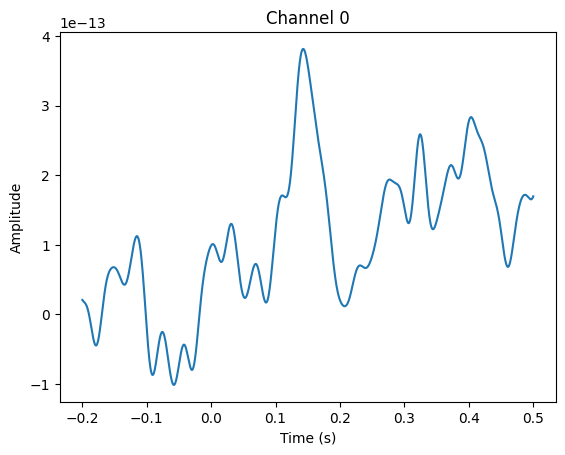

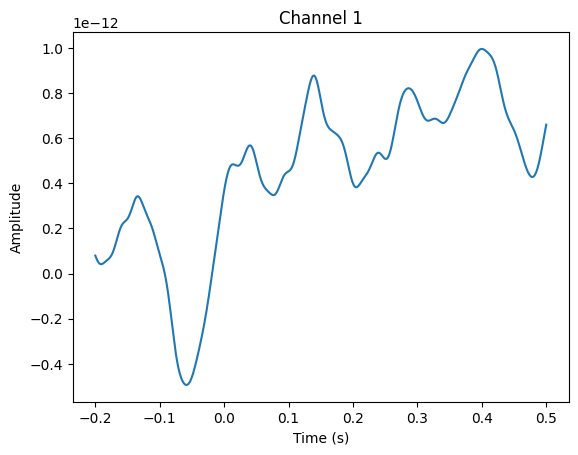

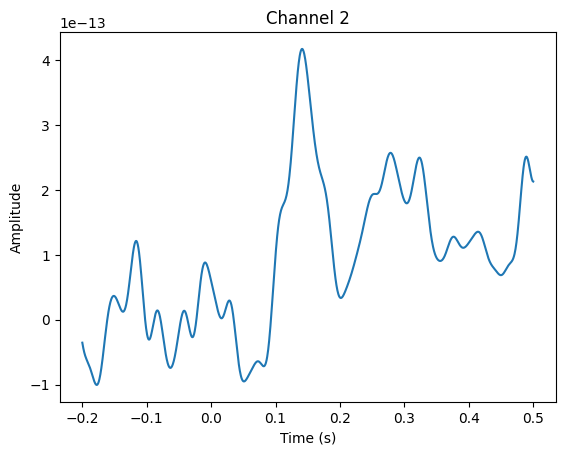

In [4]:
times = tensor["times"]

for ch in [0,1,2]:
    plt.figure()
    plt.plot(times, erp[ch])
    plt.title(f"Channel {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

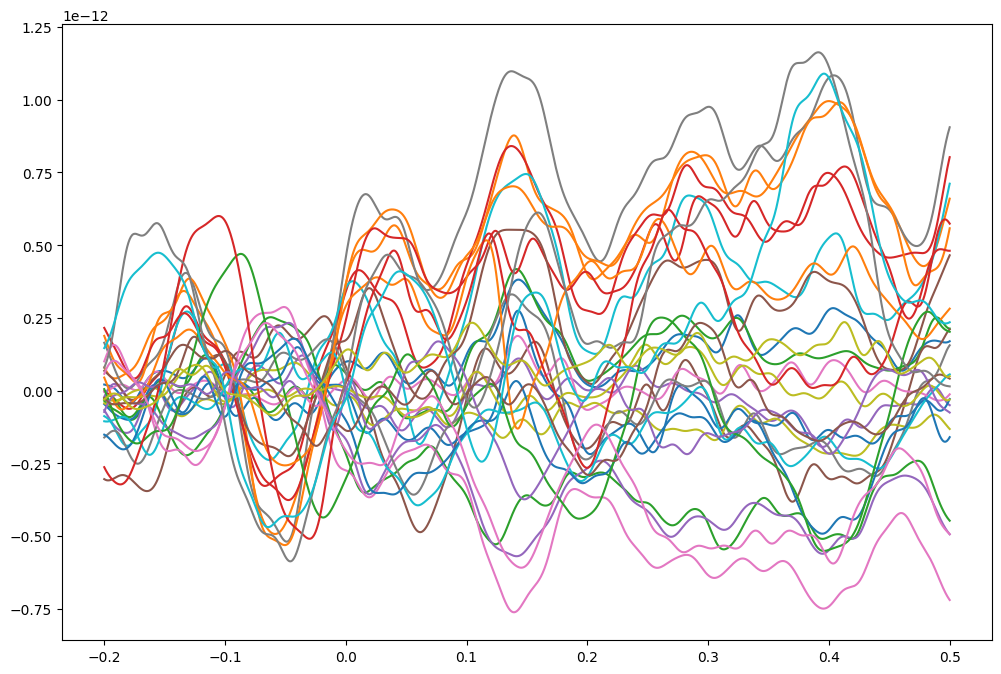

In [5]:
plt.figure(figsize=(12,8))

for ch in range(30):
    plt.plot(times, erp[ch])

plt.show()

These plots verify that
preprocessing succeeded,
the expected auditory response is visible,
different sensors observe different magnetic field patterns.


## CP Decomposition

CP approximates the tensor as a sum of rank-one tensors.

Mathematically,
$
X
\approx
\sum_{r=1}^{R}
\lambda_r
a_r
\circ
b_r
\circ
c_r
$

- R = rank
- $a_r$  = trial factor
- $b_r$ = sensor factor
- $c_r$  = temporal factor
- $\circ$ = outer product

The algorithm then iteratively updates the factor matrices until the tensor approximation stabilizes or the maximum number of iterations is reached.

In [6]:
X = tensor["epochs"]

cp = parafac(
    X,
    rank=5, # rank 5
    init="svd",
    n_iter_max=500
)

weights, factors = cp

trial_factors, sensor_factors, temporal_factors = factors

After decomposition, the tensor is represented by three factor matrices.
- The trial factor matrix describes how strongly each component contributes to each experimental trial.
- The sensor factor matrix identifies groups of sensors that tend to vary together.
- The temporal factor matrix contains the time courses associated with each component.

Each temporal component is plotted to visualize the temporal dynamics captured by the decomposition.

In [7]:
print(trial_factors.shape)
print(sensor_factors.shape)
print(temporal_factors.shape)

(200, 5)
(30, 5)
(1401, 5)


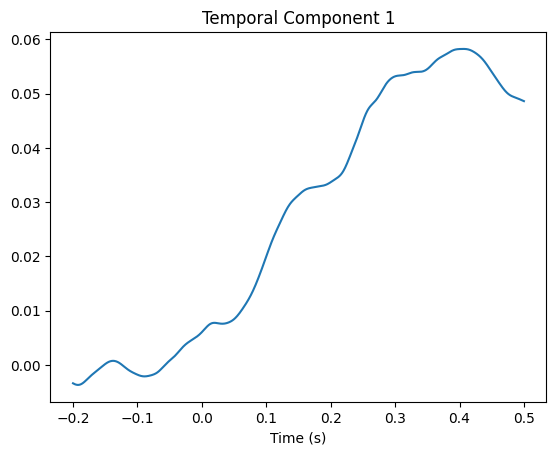

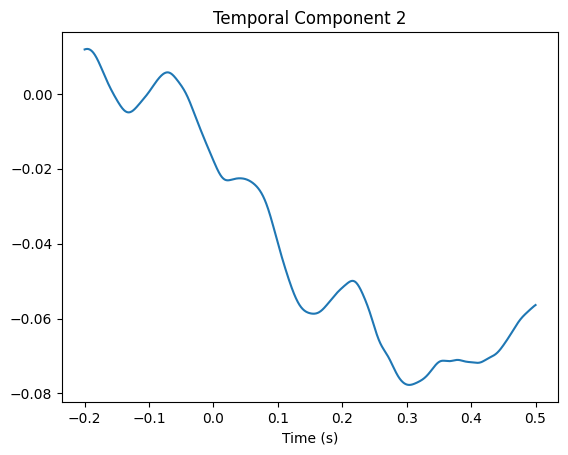

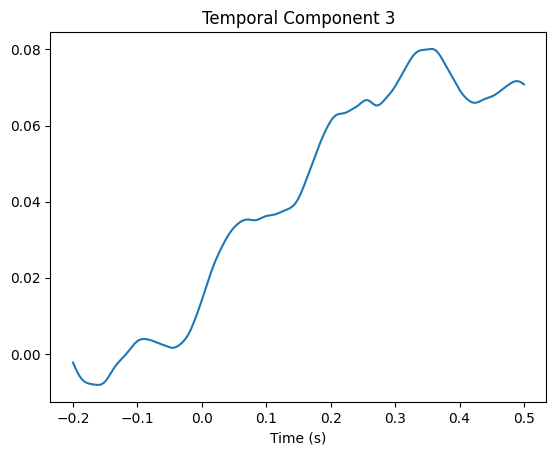

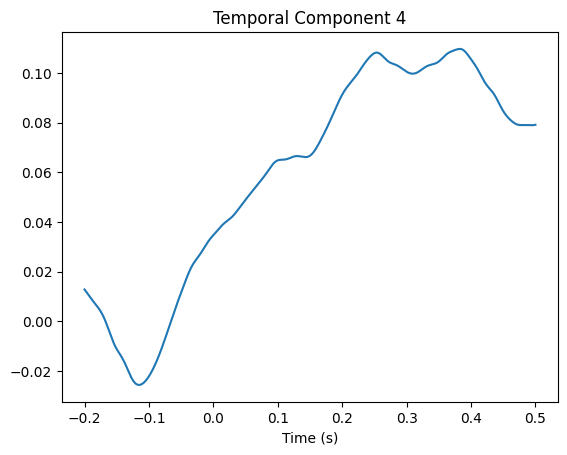

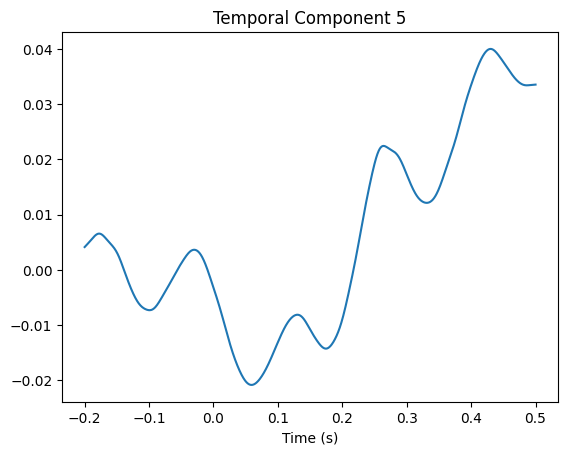

In [8]:
times = tensor["times"]

for r in range(5):
    plt.figure()
    plt.plot(times, temporal_factors[:, r])
    plt.title(f"Temporal Component {r+1}")
    plt.xlabel("Time (s)")
    plt.show()

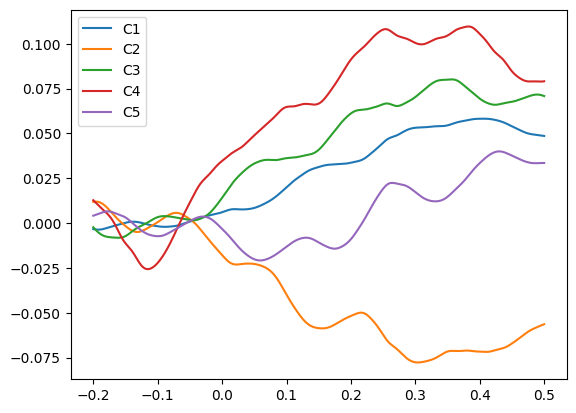

In [9]:
for r in range(5):
    plt.plot(
        times,
        temporal_factors[:, r],
        label=f"C{r+1}"
    )

plt.legend()

The reconstruction error is then calculated as

$
\frac
{
\|X-\hat{X}\|
}
{
\|X\|}
$

where

- $X$ is the original tensor,
- $\hat{X}$ is the reconstructed tensor.

A smaller reconstruction error indicates that the chosen CP rank preserves more of the original information.

Reconstruction Error

In [10]:
import tensorly as tl
from tensorly.cp_tensor import cp_to_tensor

X_cp = cp_to_tensor(cp)
cp_error = tl.norm(X - X_cp) / tl.norm(X)
print(cp_error)

0.5208050342905327


## Tucker Decomposition

Unlike CP, Tucker does not constrain every mode to have the same rank.
Instead, we specified
- 10 trial components,
- 5 sensor components,
- 20 temporal components.

The Tucker model represents the tensor as

$
X
\approx
G
\times_1
A
\times_2
B
\times_3
C
$

where

G is the core tensor,
A, B, and C are factor matrices.

The core tensor allows interactions between components from different modes, making Tucker considerably more flexible than CP.

In [11]:
core, factors = tucker(
    X,
    rank=[10,5,20]
)

Reconstruction error

In [ ]:
tucker_model = tucker(X, rank=[10,5,20])

X_tucker = tucker_to_tensor(tucker_model)

tucker_error = tl.norm(X - X_tucker) / tl.norm(X)

print(tucker_error)

0.38899026067969855


## Tensor Train (TT) Decomposition

Tensor Train represents a tensor as a sequence of low-order tensors connected through shared ranks.
Rather than decomposing the tensor into independent factor matrices, TT stores the tensor as a chain of smaller tensors.

This representation is particularly attractive for high-dimensional data because storage scales approximately linearly with tensor order instead of exponentially.

$$
X(i_1,\ldots,i_d)
=
G_1(i_1)
G_2(i_2)
\cdots
G_d(i_d)
$$

Each $G_i$ is a small core tensor connected by bond dimensions.

In [19]:
tt = tensor_train(
    X,
    rank=[1, 4, 4, 1]
)

Reconstruction Error

In [ ]:
tt = tensor_train(X, rank=[1,4,4,1])

X_tt = tt_to_tensor(tt)

tt_error = tl.norm(X - X_tt) / tl.norm(X)

print(tt_error)

0.5429803667825156
